# Week-50

[INFO] Found 290 CSV files. Plotting at most 5.


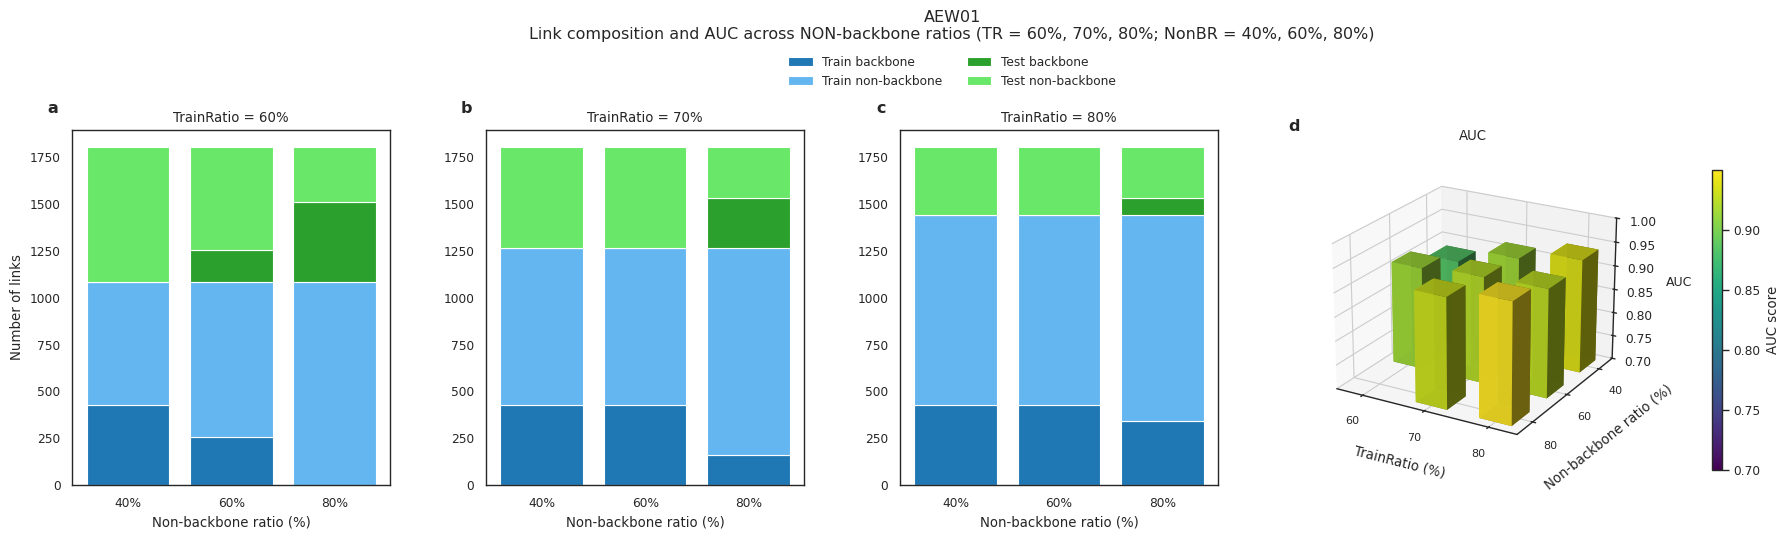

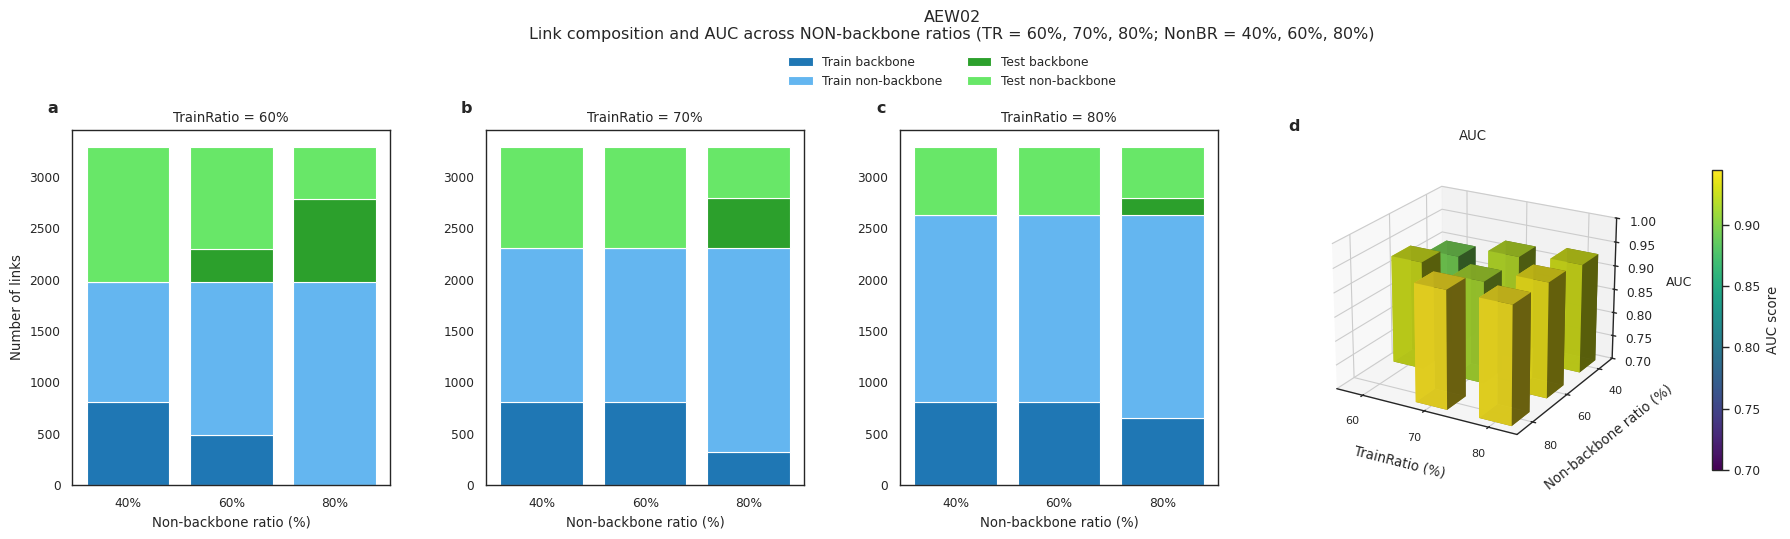

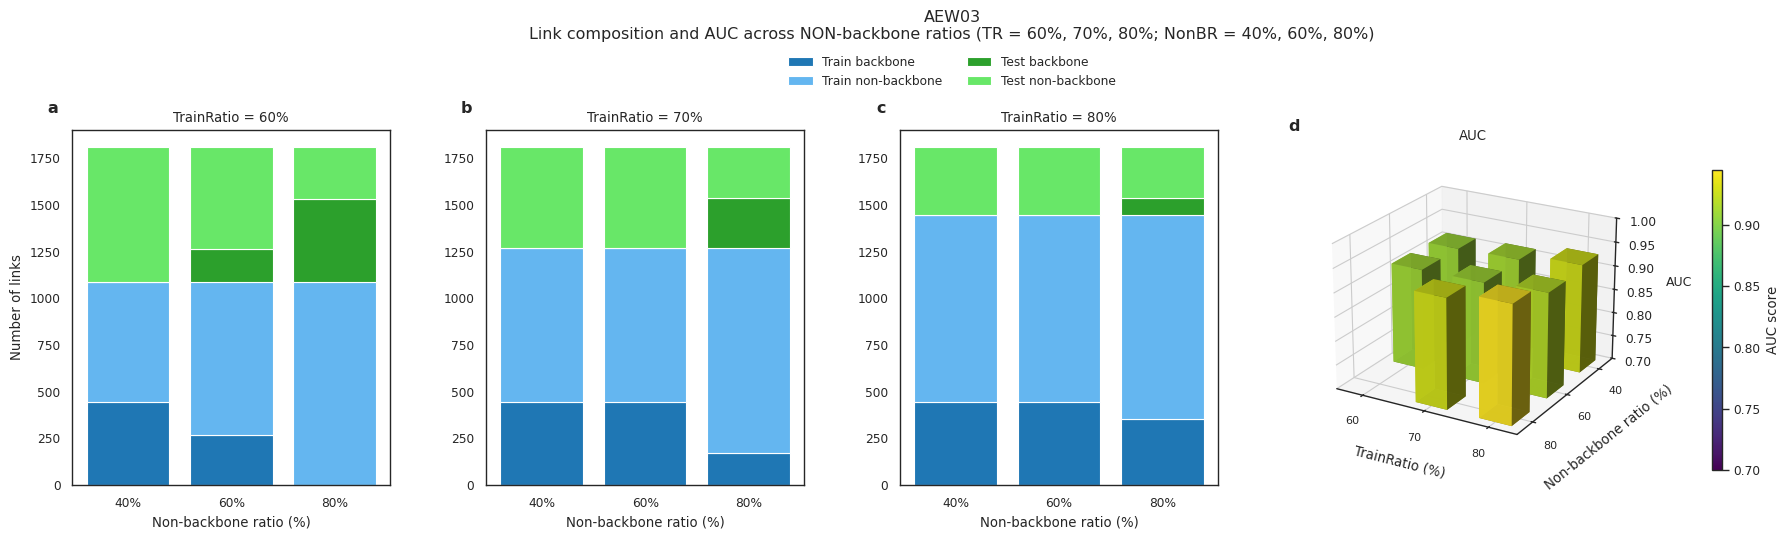

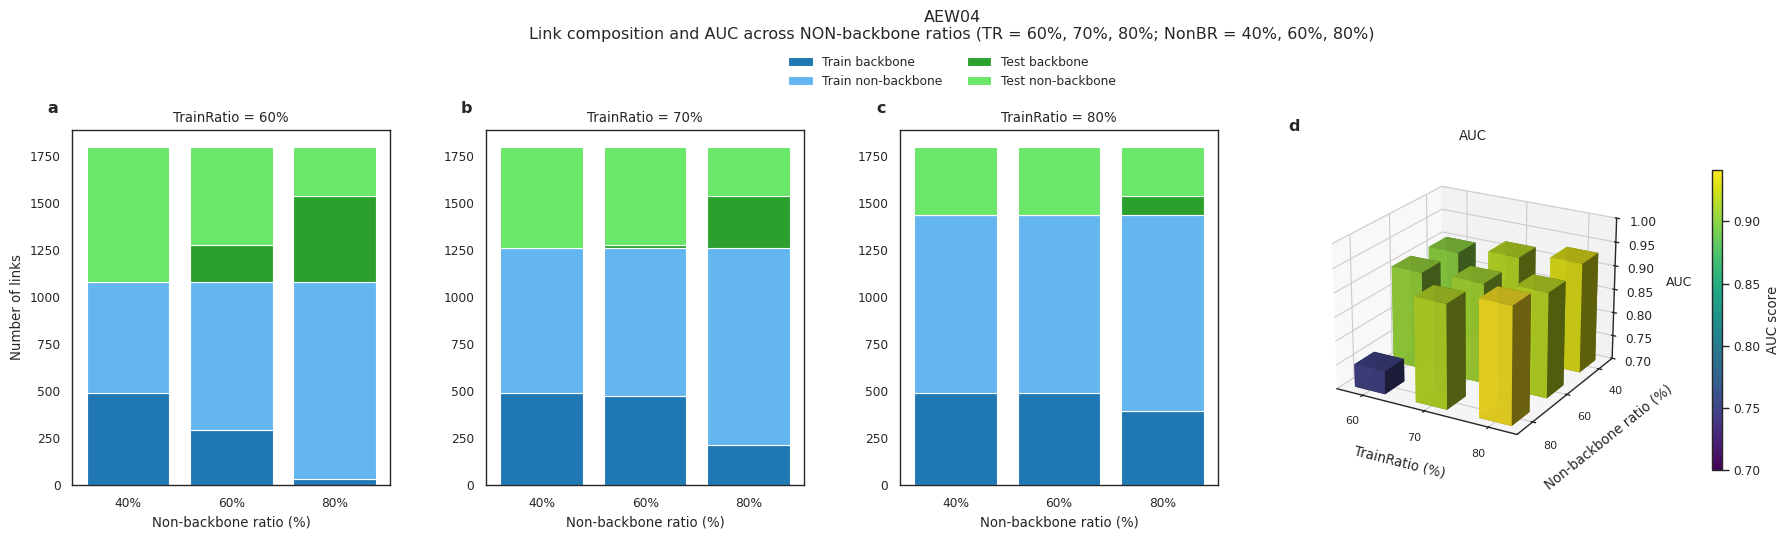

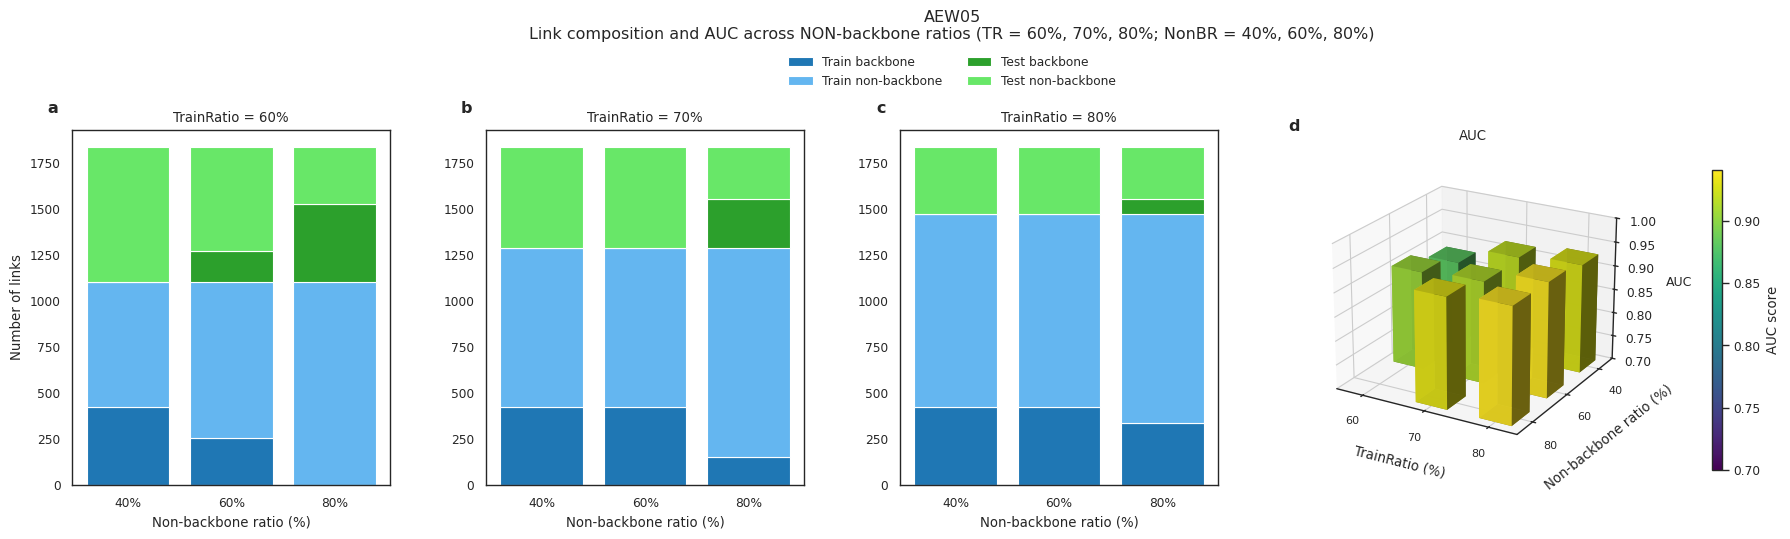

[INFO] Reached plot limit (5). Stopping.


In [1]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
from matplotlib import cm, colors

sns.set_context("paper")
sns.set_style("white")

# Optional font config (similar style to your 3D script)
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
mpl.rcParams["mathtext.fontset"] = "dejavusans"
mpl.rcParams["axes.unicode_minus"] = False

# === 0. Folder + patterns and limit ===
LOG_DIR = (
    "../../src/matlab/data/"
    "result/"
    "prediction_scores_logs"
)
GLOB_PATTERNS = [
    "*_results_random.csv",
    "*_results_*.csv",
    "*_result_*.csv",
]
MAX_PLOTS = 5  # avoid flooding VSCode

# Collect files
files = []
for pat in GLOB_PATTERNS:
    files.extend(glob.glob(os.path.join(LOG_DIR, pat)))
files = sorted(set(files))

if not files:
    raise FileNotFoundError(f"No CSV results found in {LOG_DIR}")

print(f"[INFO] Found {len(files)} CSV files. Plotting at most {MAX_PLOTS}.")

# === 1. Config: train ratios and (now) NON-backbone ratios ===
TRAIN_RATIOS = [60, 70, 80]

# We want to look at NonBackboneRatio jumps: 40%, 60%, 80%
NONBACKBONE_TARGETS = [40, 60, 80]

# Optional: fixed colors so all panels look consistent
colors_stacked = {
    "Train backbone":      "#1f77b4",
    "Train non-backbone":  "#64b6f0",
    "Test backbone":       "#2ca02c",
    "Test non-backbone":   "#68e768",
}

# 3D bar appearance
DX = DY = 0.5
FLOOR = 0.7
VIEW_KW = dict(elev=22, azim=-60)

panel_labels = ["a", "b", "c", "d"]   # a–c for stacked, d for 3D

def to_num(s: pd.Series) -> pd.Series:
    """Convert strings like '60', '60%', '0.6' to numeric."""
    return pd.to_numeric(
        s.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

# === 2. Loop over CSV files ===
for idx, PATH in enumerate(files, start=1):
    if idx > MAX_PLOTS:
        print(f"[INFO] Reached plot limit ({MAX_PLOTS}). Stopping.")
        break

    # --- Load CSV ---
    df = pd.read_csv(PATH)

    # We will ALWAYS plot NonBackboneRatio on the x-axis.
    # If it doesn't exist, derive it as 100 - BackboneRatio (handling 0–1 or 0–100).
    if "NonBackboneRatio" in df.columns:
        ratio_col = "NonBackboneRatio"
        RB_TARGETS = NONBACKBONE_TARGETS
        ratio_label = "Non-backbone ratio (%)"
    elif "BackboneRatio" in df.columns:
        bb_vals = to_num(df["BackboneRatio"])
        # If backbone ratio is in [0, 1], convert to [0, 100] first
        if bb_vals.max() <= 1.0:
            bb_vals = bb_vals * 100
        df["NonBackboneRatio"] = 100 - bb_vals
        ratio_col = "NonBackboneRatio"
        RB_TARGETS = NONBACKBONE_TARGETS
        ratio_label = "Non-backbone ratio (%)"
    else:
        print(f"[WARN] Skipping {PATH}: no BackboneRatio / NonBackboneRatio column.")
        continue

    # Check link-count columns
    group_cols = ["TrainRatio", ratio_col]
    agg_cols = [
        "TotalLinks", "TrainLinks", "TestLinks",
        "BackboneTotal", "NonBackboneTotal",
        "BackboneTrainLinks", "NonBackboneTrainLinks",
        "BackboneTestLinks", "NonBackboneTestLinks",
    ]
    missing_agg = [c for c in agg_cols if c not in df.columns]
    if missing_agg:
        print(f"[WARN] Skipping {PATH}: missing columns {missing_agg}")
        continue

    dfg = df[group_cols + agg_cols].drop_duplicates()

    # === Create subplots row for THIS file ===
    fig = plt.figure(figsize=(20, 5))
    axes = []
    for i in range(3):
        ax = fig.add_subplot(1, 4, i + 1)
        axes.append(ax)
    ax3d = fig.add_subplot(1, 4, 4, projection="3d")
    axes.append(ax3d)

    # --- 2D STACKED BAR PANELS (a, b, c) ---
    for ax, TR_TARGET, panel in zip(axes[:3], TRAIN_RATIOS, panel_labels[:3]):
        # Filter rows for this TrainRatio and the chosen NON-backbone ratios
        rows = dfg[
            (dfg["TrainRatio"] == TR_TARGET) &
            (dfg[ratio_col].isin(RB_TARGETS))
        ].sort_values(ratio_col)

        if rows.empty:
            ax.set_title(f"TrainRatio = {TR_TARGET}% (no data)")
            ax.set_xticks([])
            continue

        # Prepare stacked data
        x = np.arange(len(rows))
        xtick_labels = [f"{int(r)}%" for r in rows[ratio_col]]

        train_bb = rows["BackboneTrainLinks"].to_numpy()
        train_nb = rows["NonBackboneTrainLinks"].to_numpy()
        test_bb  = rows["BackboneTestLinks"].to_numpy()
        test_nb  = rows["NonBackboneTestLinks"].to_numpy()

        # Stacked bars for this TrainRatio
        ax.bar(
            x, train_bb,
            color=colors_stacked["Train backbone"],
            label="Train backbone"
        )
        ax.bar(
            x, train_nb,
            bottom=train_bb,
            color=colors_stacked["Train non-backbone"],
            label="Train non-backbone"
        )
        ax.bar(
            x, test_bb,
            bottom=train_bb + train_nb,
            color=colors_stacked["Test backbone"],
            label="Test backbone"
        )
        ax.bar(
            x, test_nb,
            bottom=train_bb + train_nb + test_bb,
            color=colors_stacked["Test non-backbone"],
            label="Test non-backbone"
        )

        # Headroom so bars don't touch the ceiling
        total_stack = train_bb + train_nb + test_bb + test_nb
        ymax = total_stack.max()
        ax.set_ylim(0, ymax * 1.05)

        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels)
        ax.set_xlabel(ratio_label)
        ax.set_title(f"TrainRatio = {TR_TARGET}%")

        # Bold panel letter
        ax.annotate(
            panel,
            xy=(0, 1), xycoords="axes fraction",
            xytext=(-10, 10), textcoords="offset points",
            ha="right", va="bottom",
            fontsize="large",
            fontweight="bold",
            annotation_clip=False,
        )

    axes[0].set_ylabel("Number of links")

    # --- 3D PANEL (d): AUC vs TrainRatio × NonBackboneRatio ---
    if "AUC" in df.columns:
        df_auc = df.copy()
        df_auc["TR"] = to_num(df_auc["TrainRatio"])
        df_auc["BR"] = to_num(df_auc[ratio_col])  # here BR = NonBackboneRatio

        # Normalize to percentages if needed
        for col in ["TR", "BR"]:
            vals = df_auc[col].dropna()
            if len(vals) and vals.max() <= 1.0:
                df_auc[col] = df_auc[col] * 100

        df_auc = df_auc[
            df_auc["TR"].isin(TRAIN_RATIOS) &
            df_auc["BR"].isin(RB_TARGETS)
        ]

        if df_auc.empty:
            ax3d.text2D(
                0.5, 0.5,
                "No AUC data\nfor selected TR/NonBR",
                transform=ax3d.transAxes,
                ha="center", va="center"
            )
        else:
            pivot_auc = (
                df_auc.groupby(["TR", "BR"], as_index=False)["AUC"]
                      .mean()
                      .pivot(index="TR", columns="BR", values="AUC")
                      .reindex(index=TRAIN_RATIOS, columns=RB_TARGETS)
            )

            xr = np.array(TRAIN_RATIOS)
            yr = np.array(RB_TARGETS[::-1])  # descending NonBackboneRatio

            vmax = float(np.nanmax(pivot_auc.values))
            cmap = cm.viridis
            norm = colors.Normalize(vmin=FLOOR, vmax=vmax)

            xs, ys, zs, dzh, cols = [], [], [], [], []

            for i, tr in enumerate(xr):
                for j, br in enumerate(yr):
                    if br not in pivot_auc.columns:
                        continue
                    val = pivot_auc.loc[tr, br]
                    if np.isnan(val):
                        continue
                    height = val - FLOOR
                    if height <= 0:
                        continue
                    xs.append(i - DX / 2)
                    ys.append(j - DY / 2)
                    zs.append(FLOOR)
                    dzh.append(height)
                    cols.append(cmap(norm(val)))

            if xs:
                ax3d.bar3d(xs, ys, zs, DX, DY, dzh,
                           shade=True, color=cols,
                           edgecolor="none", alpha=0.95)

                ax3d.set_title("AUC")
                ax3d.set_xlabel("TrainRatio (%)", labelpad=6)
                ax3d.set_ylabel("Non-backbone ratio (%)", labelpad=6)
                ax3d.set_zlabel("AUC", labelpad=8, fontsize=9)

                ax3d.set_xticks(range(len(xr)))
                ax3d.set_xticklabels([f"{int(v)}" for v in xr], fontsize=8)
                ax3d.set_yticks(range(len(yr)))
                ax3d.set_yticklabels([f"{int(v)}" for v in yr], fontsize=8)

                ax3d.set_zlim(FLOOR, 1.0)
                ax3d.view_init(**VIEW_KW)

                # Panel letter (d)
                ax3d.annotate(
                    panel_labels[3],
                    xy=(0, 1), xycoords="axes fraction",
                    xytext=(-10, 10), textcoords="offset points",
                    ha="right", va="bottom",
                    fontsize="large",
                    fontweight="bold",
                    annotation_clip=False,
                )

                # Colorbar
                mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
                mappable.set_array([])
                cbar_ax = fig.add_axes([0.88, 0.18, 0.005, 0.60])
                cb = fig.colorbar(mappable, cax=cbar_ax, aspect=10)
                cb.set_label("AUC score", rotation=90)
    else:
        ax3d.text2D(
            0.5, 0.5,
            "No AUC column\nin this CSV",
            transform=ax3d.transAxes,
            ha="center", va="center"
        )

    base = os.path.splitext(os.path.basename(PATH))[0]
    base = base.replace("_tax_mass_results_random", "").strip(" _")

    fig.suptitle(
        f"{base}\n"
        "Link composition and AUC across NON-backbone ratios "
        "(TR = 60%, 70%, 80%; NonBR = 40%, 60%, 80%)",
        y=1.1
    )

    handles, labels = axes[2].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=2,
        frameon=False
    )

    fig.subplots_adjust(
        left=0.06,
        right=0.84,
        bottom=0.15,
        top=0.86,
        wspace=0.30
    )

    plt.show()